# Random Forest

## Overview

**Random Forest** is an ensemble learning method that builds a collection of Decision Trees and aggregates their predictions. By combining many decorrelated trees, it dramatically reduces the variance of individual trees while keeping bias low — achieving much stronger generalization than any single tree.

Random Forests are among the most practical and widely deployed algorithms in machine learning, performing well across a broad range of tasks with little hyperparameter tuning.

---

## Core Idea — Wisdom of the Crowd

A single deep Decision Tree is a high-variance model — it memorizes training data and is sensitive to noise. Random Forest addresses this through two randomization mechanisms:

1. **Bootstrap Aggregation (Bagging)** — each tree is trained on a random sample with replacement from the training set. On average, each tree sees ~63.2% of the data; the remaining ~36.8% form the **out-of-bag (OOB)** set.

2. **Feature Subsampling** — at each split, only a random subset of $\sqrt{p}$ features (for classification) are considered. This decorrelates the trees so their errors do not all point in the same direction.

---

## Prediction Aggregation

**Classification — majority vote:**

$$\hat{y} = \text{mode}\left\{ h_1(\mathbf{x}),\, h_2(\mathbf{x}),\, \dots,\, h_B(\mathbf{x}) \right\}$$

**Regression — mean:**

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} h_b(\mathbf{x})$$

where $h_b$ is the $b$-th tree and $B$ is the number of trees.

---

## Out-of-Bag (OOB) Score

Because each tree is trained on a bootstrap sample, the samples not included (~36.8%) form a natural validation set. The OOB score is an unbiased estimate of generalization performance computed without a separate validation split:

$$\text{OOB Score} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\left[\hat{y}_i^{\text{oob}} = y_i\right]$$

---

## Feature Importance

Feature importance is averaged across all trees:

$$\text{Importance}(j) = \frac{1}{B} \sum_{b=1}^{B} \text{Importance}_b(j)$$

where each tree's importance is the weighted impurity reduction from splits on feature $j$.

---

## Key Properties

| Property | Detail |
|---|---|
| **Type** | Ensemble of Decision Trees |
| **Variance reduction** | Bagging + feature subsampling |
| **Supports** | Classification and regression |
| **Feature importance** | Built-in, reliable |
| **OOB estimate** | Free validation without a held-out set |
| **Limitation** | Less interpretable than a single tree; slower than single models |

 EXPERIMENT 1 — Random Forest vs Decision Tree


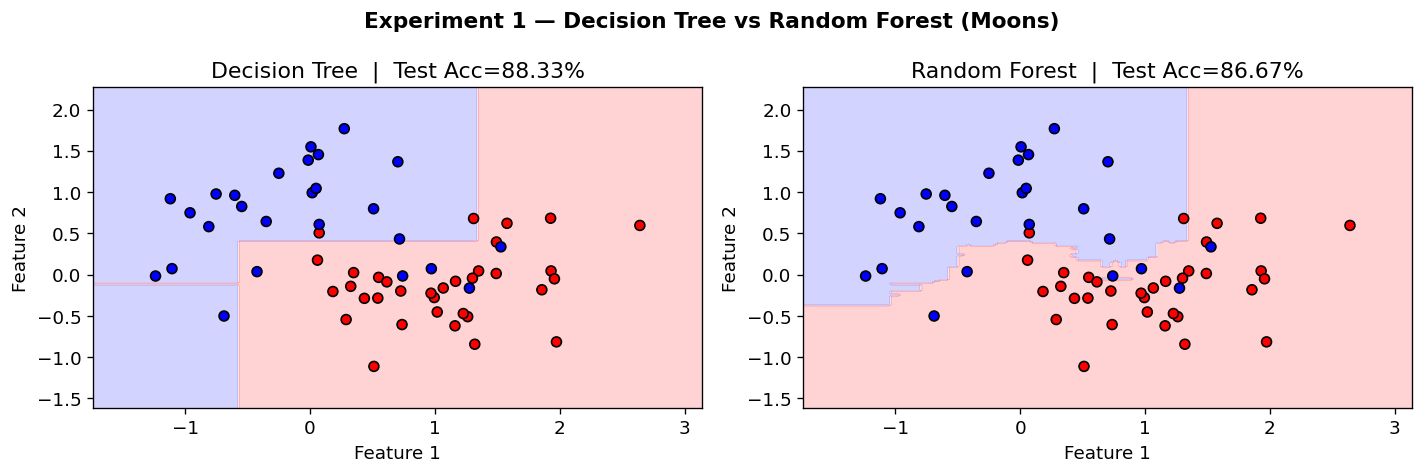

Decision Tree  Test Acc: 88.33%
Random Forest  Test Acc: 86.67%

 EXPERIMENT 2 — Effect of n_trees


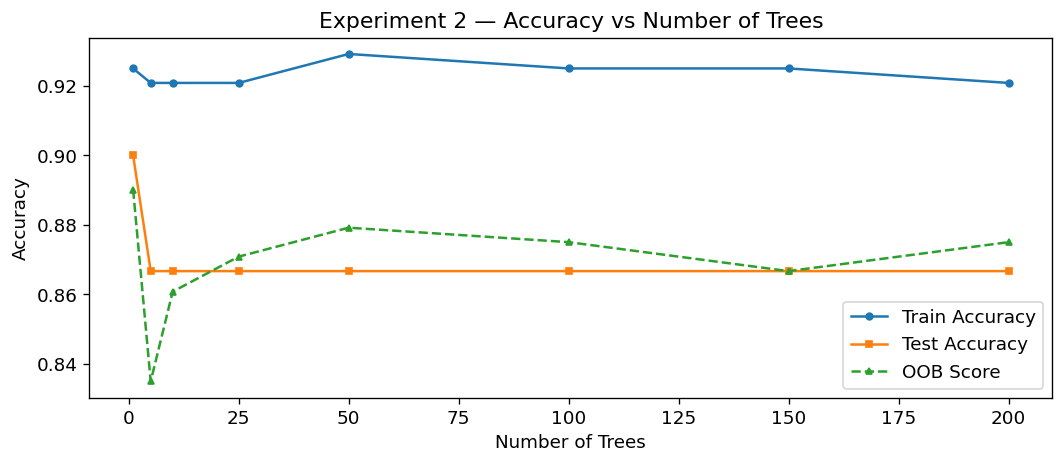

 EXPERIMENT 3 — Feature Importances (Iris)


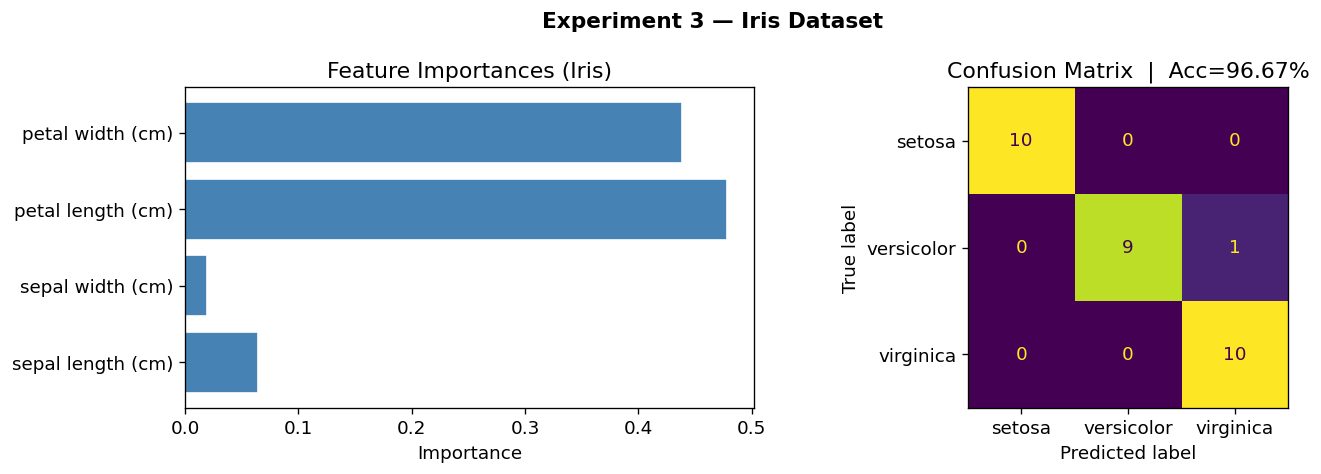

Iris Test Accuracy: 96.67%

 EXPERIMENT 4 — Breast Cancer Dataset
Test Accuracy : 94.74%
OOB Score     : 96.26%

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



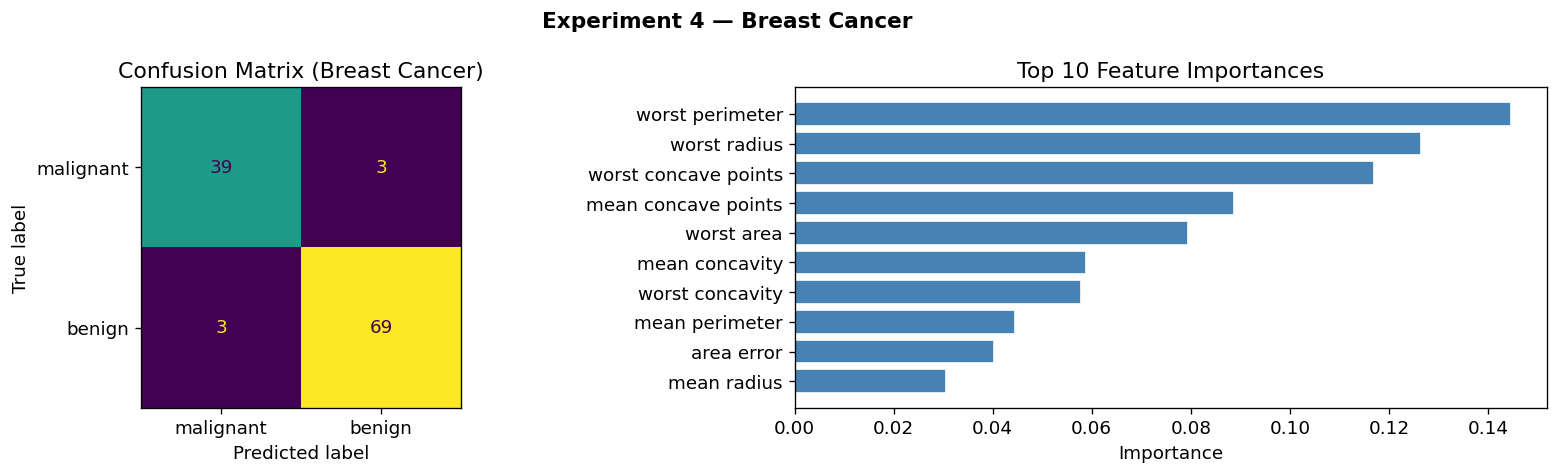

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.supervised_learning.random_forest import RandomForest
from mlpackage.supervised_learning.decision_tree import DecisionTree

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper ────────────────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. Random Forest vs Decision Tree ────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Random Forest vs Decision Tree")
print("=" * 55)

X_moon, y_moon = make_moons(n_samples=300, noise=0.3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

dt  = DecisionTree(max_depth=5, random_state=0)
rf  = RandomForest(n_trees=100, max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)
rf.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_decision_boundary(dt, X_te, y_te, axes[0],
    f"Decision Tree  |  Test Acc={dt.score(X_te, y_te):.2%}")
plot_decision_boundary(rf, X_te, y_te, axes[1],
    f"Random Forest  |  Test Acc={rf.score(X_te, y_te):.2%}")
plt.suptitle("Experiment 1 — Decision Tree vs Random Forest (Moons)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Decision Tree  Test Acc: {dt.score(X_te, y_te):.2%}")
print(f"Random Forest  Test Acc: {rf.score(X_te, y_te):.2%}\n")


# ── 2. Effect of n_trees ──────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Effect of n_trees")
print("=" * 55)

tree_counts = [1, 5, 10, 25, 50, 100, 150, 200]
train_accs, test_accs, oob_scores = [], [], []
for n in tree_counts:
    model = RandomForest(n_trees=n, max_depth=5, random_state=42)
    model.fit(X_tr, y_tr, oob_score=True)
    train_accs.append(model.score(X_tr, y_tr))
    test_accs.append(model.score(X_te, y_te))
    oob_scores.append(model.oob_score_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tree_counts, train_accs, marker="o", markersize=4, label="Train Accuracy")
ax.plot(tree_counts, test_accs,  marker="s", markersize=4, label="Test Accuracy")
ax.plot(tree_counts, oob_scores, marker="^", markersize=4, linestyle="--", label="OOB Score")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment 2 — Accuracy vs Number of Trees")
ax.legend()
plt.tight_layout()
plt.show()


# ── 3. Feature Importances — Iris ────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Feature Importances (Iris)")
print("=" * 55)

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

rf_iris = RandomForest(n_trees=100, max_depth=5, random_state=42)
rf_iris.fit(X_tr_i, y_tr_i)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(iris.feature_names, rf_iris.feature_importances_,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Importance")
axes[0].set_title("Feature Importances (Iris)")

ConfusionMatrixDisplay(
    confusion_matrix(y_te_i, rf_iris.predict(X_te_i)),
    display_labels=iris.target_names
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix  |  Acc={rf_iris.score(X_te_i, y_te_i):.2%}")

plt.suptitle("Experiment 3 — Iris Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Iris Test Accuracy: {rf_iris.score(X_te_i, y_te_i):.2%}\n")


# ── 4. Real Dataset — Breast Cancer ──────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Breast Cancer Dataset")
print("=" * 55)

data = load_breast_cancer()
X_b, y_b = data.data, data.target
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)

rf_bc = RandomForest(n_trees=100, max_depth=8, random_state=42)
rf_bc.fit(X_tr_b, y_tr_b, oob_score=True)
y_pred_bc = rf_bc.predict(X_te_b)

print(f"Test Accuracy : {rf_bc.score(X_te_b, y_te_b):.2%}")
print(f"OOB Score     : {rf_bc.oob_score_:.2%}\n")
print(classification_report(y_te_b, y_pred_bc, target_names=data.target_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te_b, y_pred_bc),
                       display_labels=data.target_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Breast Cancer)")

top_n = 10
top_idx = np.argsort(rf_bc.feature_importances_)[-top_n:]
axes[1].barh(np.array(data.feature_names)[top_idx],
             rf_bc.feature_importances_[top_idx],
             color="steelblue", edgecolor="white")
axes[1].set_xlabel("Importance")
axes[1].set_title(f"Top {top_n} Feature Importances")
plt.suptitle("Experiment 4 — Breast Cancer", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()